In [1]:
%load_ext autoreload
%autoreload 2

import re
import numpy as np
import pandas as pd
import scipy.sparse
from statsmodels.stats.multitest import multipletests
import scanpy as sc
import seaborn as sns   
from scipy import stats
import statsmodels.formula.api as smf
import matplotlib.pyplot as plt
import gc

import sys
sys.path.insert(0, '/home/gdallagl/myworkdir/XDP/script/NucSeq/de-repression/')

import derepression_functions

In [3]:
SAMPLE_VARIABLE  = "donor_id"
AGE              = "age_of_death"
ZONE_COL         = "zone"
LIBRARY_SIZE_COL = "total_counts"
CONDITION        = "condition"
HEALTHY_CONDITION    = "healthy"
DISEASED_CONDITION    = "diseased"
ZONE_COL = "zone"

# BICAN - Cocariates for determining G (gene of derepsse gene in bican -H)
COVARIATE_COLS = ["sex", "PC1", "PC2", "PC3", "PC4", "PC5"] # in addtion to mean log umi and squared version



# Load Bican

In [ ]:
BICAN_PATH = "/home/gdallagl/myworkdir/XDP/data/BICAN/STR_D1_Matrix/d1_cleaner_v3_raw_dv_wm_labeled.h5ad"

bican = sc.read_h5ad(BICAN_PATH)

print(bican.X[:200, :200].toarray().sum(axis=1))

# bican.X = bican.layers["counts"].astype("int32", copy=False)

# Rename columns to a consistent naming convention
bican.obs = bican.obs.rename(columns={
    "merge_step_6" : ZONE_COL,
    "donor_id"     : SAMPLE_VARIABLE,
    "age"          : AGE,
    "n_counts"     : LIBRARY_SIZE_COL,
    "imputed_sex"  : "sex",
})
# ATTENTION: all healthy
bican.obs[CONDITION] = HEALTHY_CONDITION

# gene are gene_symbols

print(bican)
print(f"\nDonors : {bican.obs[SAMPLE_VARIABLE].nunique()}")
print(f"Zones  : {sorted(bican.obs[ZONE_COL].unique())}")
print(f"Age range: {bican.obs[AGE].min():.0f}–{bican.obs[AGE].max():.0f}")

[ 869. 1220. 1391. 1573.  850.  497. 1197. 1929. 1083. 1105. 1068. 1222.
 1109. 1095. 1025. 1248.  452.  976. 1488. 1528. 1488.  984. 1392. 1222.
 1307. 1512. 1272. 1072.  899. 1129.  997. 1089. 1327. 1256.  880. 1297.
 1248.  818. 1184. 1287. 1496. 1256. 1430. 1002. 1053. 1180. 1340.  980.
 1271. 1358. 1150. 1280. 1121. 1026.  940. 1312. 1253. 1621.  655.  959.
 1665. 1022. 1131.  946. 1376.  889.  482. 1193. 1320. 1300. 1404.  870.
  935. 1529.  710. 1467.  986. 1451. 1202.  384. 1038. 1594.  972. 1689.
 1149. 1622.  798.  929. 1730. 1200.  854.  570.  810. 1024. 1069.  609.
 1161. 1142. 1125. 1058.  870.  879. 1170.  592. 1031.  683.  704. 1361.
 1331. 1122. 1323. 1578. 1180. 1226. 1194. 1214. 1149. 1047. 1266.  770.
  913. 1165.  955.  405. 1380. 1125. 1172. 1459. 1446. 1159. 1649. 1127.
 1014. 1237. 1049. 1289. 1219. 1009.  866. 1200. 1547. 1127. 1420. 1061.
 1240. 1022.  766.  816. 1195. 1162. 1102. 1138.  778.  965. 1215. 1260.
 1017. 1157. 1276. 1155. 1648.  710. 1232. 1659.  7

In [4]:
# ATTENTION: PCs are SNP
bican[bican.obs[SAMPLE_VARIABLE] == "MS652464"].obs.PC1

v12_10X-GEMX-3P_CaH_CTGCAAATCGTGCCTC        -0.0105
v12_10X-GEMX-3P_CaH_CGTTCAGGTCCATTAA        -0.0105
v12_10X-GEMX-3P_CaH_ATAGGCCTCCTCAGCC        -0.0105
v12_10X-GEMX-3P_CaH_TCATTCGCAACTGTCC        -0.0105
v12_10X-GEMX-3P_CaH_CAATTGGTCTGGTAAT        -0.0105
                                              ...  
v67_10X-GEMX-3P_NAC_rxn4_CTTACTATCCGCGACA   -0.0105
v67_10X-GEMX-3P_NAC_rxn4_GCTACTGGTCTAGGCC   -0.0105
v67_10X-GEMX-3P_NAC_rxn4_TAAGCGGAGGTCAAGG   -0.0105
v67_10X-GEMX-3P_NAC_rxn4_GCCATTCCATCGTTGC   -0.0105
v67_10X-GEMX-3P_NAC_rxn4_CGTCAAATCCATGTGA   -0.0105
Name: PC1, Length: 658, dtype: float64

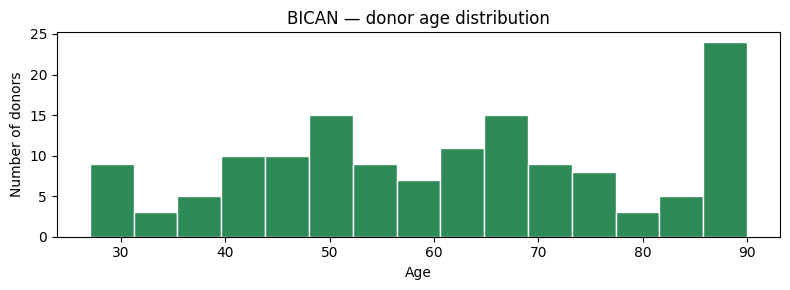

In [5]:
import matplotlib.pyplot as plt


# Quick overview of donor ages across the full dataset
donor_meta = bican.obs.drop_duplicates(SAMPLE_VARIABLE)[[SAMPLE_VARIABLE, AGE]].copy()
donor_meta[AGE] = donor_meta[AGE].astype(float)

fig, ax = plt.subplots(figsize=(8, 3))
ax.hist(donor_meta[AGE], bins=15, color="seagreen", edgecolor="white")
ax.set_xlabel("Age")
ax.set_ylabel("Number of donors")
ax.set_title("BICAN — donor age distribution")
plt.tight_layout()
plt.show()

# Bican H - Analysis

In [ ]:
THR_DR = [0.02, 0.05, 0.1]
MIN_CELL_PER_SAMPLE = 30
N_PERM = 10_000
FDR_ALPHA = 0.05
SEED = 42
DEREPRESSION_SCORE_METHOD = ["ucell", "scanpy_score", "gene_count"]#, "ucell"]

ZONES = sorted(bican.obs[ZONE_COL].unique().tolist())

### Find list of De-repressed genes using all STR

In [7]:
all_summaries  = {}
all_gene_lists = {}
all_results    = {}       
all_models     = {}

for i_thr, thr in enumerate(THR_DR, 1):
        
    for score_method in DEREPRESSION_SCORE_METHOD:

        print(f"\n{i_thr}/{len(THR_DR)*len(DEREPRESSION_SCORE_METHOD)} | Threshold: {thr} | Score method: {score_method}")

        print("\tFinding depressed genes using ALL striatum…")
        gene_list, results_df, donor_meta = derepression_functions.find_depressed_genes(
            bican,
            donor_col=SAMPLE_VARIABLE, age_col=AGE, tot_UMI_per_cell_col=LIBRARY_SIZE_COL,
            covariate_cols=COVARIATE_COLS, threshold=thr, min_cells=MIN_CELL_PER_SAMPLE,
            n_perm=N_PERM, fdr_alpha=FDR_ALPHA, seed=SEED,
        )

        if not gene_list:
            print(f"  → 0 significant genes, skipping")
            continue

        for zone in ZONES:

            adata_zone = bican[bican.obs[ZONE_COL] == zone].copy()

            print(f"\tComputing scores and covariates for {zone}…")
            key = (score_method, thr, zone)
            summary = derepression_functions.compute_scores_and_cov(
                adata_zone, 
                gene_set=gene_list, donor_col=SAMPLE_VARIABLE, age_col=AGE,
                umi_col=LIBRARY_SIZE_COL, condition_col=CONDITION, cov_cols=None,
                score_method=score_method, percentile=90,
            )
            summary["score_method"] = score_method
            summary["thr"] = thr
            summary["zone"] = zone

            model = smf.ols("score_S_scaled ~ age_scaled + median_log_umi_scaled", data=summary).fit()
            b, p  = model.params["age_scaled"], model.pvalues["age_scaled"]
            print(f"\t{zone}: {len(gene_list)} genes | β={b:+.3f} p={p:.2e}")

            all_summaries[key]  = summary
            all_gene_lists[key] = gene_list
            all_results[key]    = results_df
            all_models[key]     = model

            del adata_zone
            gc.collect()

combined = pd.concat(all_summaries.values(), ignore_index=True)


1/2 | Threshold: 0.02 | Score method: gene_count
	Finding depressed genes using ALL striatum…
  Donors kept: 142  (dropped 1 with < 30 cells)
  Downsampling to 113 cells per donor


/home/gdallagl/myworkdir/XDP/script/NucSeq/de-repression/derepression_functions.py:37: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  adata_sub = adata[adata.obs.groupby(donor_col).sample(n=min_n, random_state=seed).index].copy()
/home/gdallagl/myworkdir/XDP/script/NucSeq/de-repression/derepression_functions.py:50: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  donor_meta = adata.obs.groupby(donor_col).agg(
/home/gdallagl/myworkdir/XDP/script/NucSeq/de-repression/derepression_functions.py:59: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pa

Subsampling adata to Young and Old quartiles only...
  Young (≤47): 36  |  Old (≥76): 36
  Candidates: 14220
  Running permutation test (10,000 perms)...
  Significant (padj < 0.05): 297  →  297 genes
	Computing scores and covariates for 1…
	1: 297 genes | β=+0.415 p=3.04e-08
	Computing scores and covariates for 2…
	2: 297 genes | β=+0.541 p=8.85e-14
	Computing scores and covariates for 3…
	3: 297 genes | β=+0.615 p=4.67e-14
	Computing scores and covariates for 4…
	4: 297 genes | β=+0.580 p=6.87e-18
	Computing scores and covariates for 5…
	5: 297 genes | β=+0.590 p=1.09e-13
	Computing scores and covariates for 6…
	6: 297 genes | β=+0.621 p=2.52e-15

2/2 | Threshold: 0.1 | Score method: gene_count
	Finding depressed genes using ALL striatum…
  Donors kept: 142  (dropped 1 with < 30 cells)
  Downsampling to 113 cells per donor


/home/gdallagl/myworkdir/XDP/script/NucSeq/de-repression/derepression_functions.py:37: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  adata_sub = adata[adata.obs.groupby(donor_col).sample(n=min_n, random_state=seed).index].copy()
/home/gdallagl/myworkdir/XDP/script/NucSeq/de-repression/derepression_functions.py:50: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  donor_meta = adata.obs.groupby(donor_col).agg(
/home/gdallagl/myworkdir/XDP/script/NucSeq/de-repression/derepression_functions.py:59: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pa

Subsampling adata to Young and Old quartiles only...
  Young (≤47): 36  |  Old (≥76): 36
  Candidates: 21201
  Running permutation test (10,000 perms)...
  Significant (padj < 0.05): 787  →  787 genes
	Computing scores and covariates for 1…
	1: 787 genes | β=+0.544 p=4.26e-15
	Computing scores and covariates for 2…
	2: 787 genes | β=+0.597 p=3.19e-17
	Computing scores and covariates for 3…
	3: 787 genes | β=+0.615 p=3.17e-14
	Computing scores and covariates for 4…
	4: 787 genes | β=+0.567 p=1.27e-18
	Computing scores and covariates for 5…
	5: 787 genes | β=+0.639 p=2.71e-16
	Computing scores and covariates for 6…
	6: 787 genes | β=+0.652 p=1.53e-17


In [ ]:
# all_summaries  = {}
# all_gene_lists = {}
# all_results    = {}       
# all_models     = {}

# for i_thr, thr in enumerate(THR_DR, 1):
#     for i_zone, zone in enumerate(ZONES, 1):

#         print(f"\n[thr={thr} | zone={zone}]")
#         adata_zone = bican[bican.obs[ZONE_COL] == zone].copy()

#         gene_list, results_df, donor_meta = derepression_functions.find_depressed_genes(
#             adata_zone,
#             donor_col=SAMPLE_VARIABLE, age_col=AGE, tot_UMI_per_cell_col=LIBRARY_SIZE_COL,
#             covariate_cols=COVARIATE_COLS, threshold=thr, min_cells=MIN_CELL_PER_SAMPLE,
#             n_perm=N_PERM, fdr_alpha=FDR_ALPHA, seed=SEED,
#         )

#         if not gene_list:
#             print(f"  → 0 significant genes, skipping")
#             continue

#         for score_method in DEREPRESSION_SCORE_METHOD:

#             print(f"\n  Computing scores and covariates for {score_method}…")
            
#             key = (score_method, thr, zone)
#             summary = derepression_functions.compute_scores_and_cov(
#                 adata_zone, gene_set=gene_list, donor_col=SAMPLE_VARIABLE, age_col=AGE,
#                 umi_col=LIBRARY_SIZE_COL, condition_col=CONDITION, cov_cols=None,
#                 score_method=score_method, percentile=90,
#             )
#             summary["zone"] = zone
#             summary["score_method"] = score_method
#             summary["thr"] = thr

#             model = smf.ols("score_S_scaled ~ age_scaled + median_log_umi_scaled", data=summary).fit()
#             b, p  = model.params["age_scaled"], model.pvalues["age_scaled"]
#             print(f"  {score_method}: {len(gene_list)} genes | β={b:+.3f} p={p:.2e}")

#             all_summaries[key]  = summary
#             all_gene_lists[key] = gene_list
#             all_results[key]    = results_df
#             all_models[key]     = model

# combined = pd.concat(all_summaries.values(), ignore_index=True)


### Save

In [ ]:
import os, json, pickle

OUT_DIR = "/home/gdallagl/myworkdir/XDP/data/_old/derepression_results"

In [ ]:
import os, json, pickle

OUT_DIR = "/home/gdallagl/myworkdir/XDP/data/_old/derepression_results"
os.makedirs(OUT_DIR, exist_ok=True)

pd.concat([df.assign(score_method=sm, thr=thr, zone=z) for (sm,thr,z),df in all_summaries.items()]).to_csv(f"{OUT_DIR}/summaries.csv", index=False)
pd.concat([df.assign(score_method=sm, thr=thr, zone=z) for (sm,thr,z),df in all_results.items()]).to_csv(f"{OUT_DIR}/results.csv",   index=False)
json.dump({str(k): v for k,v in all_gene_lists.items()}, open(f"{OUT_DIR}/gene_lists.json", "w"))
pickle.dump(all_models, open(f"{OUT_DIR}/models.pkl", "wb"))

In [ ]:
def rebuild(df):
    return {(sm,thr,z): g.drop(columns=["score_method","thr","zone"]).reset_index(drop=True)
            for (sm,thr,z), g in df.groupby(["score_method","thr","zone"])}

all_summaries  = rebuild(pd.read_csv(f"{OUT_DIR}/summaries.csv"))
all_results    = rebuild(pd.read_csv(f"{OUT_DIR}/results.csv"))
all_gene_lists = {eval(k): v for k,v in json.load(open(f"{OUT_DIR}/gene_lists.json")).items()}
all_models = pickle.load(open(f"{OUT_DIR}/models.pkl", "rb"))

combined = pd.read_csv(f"{OUT_DIR}/summaries.csv")  # keeps zone, score_method, thr


In [ ]:
kk

### Plot

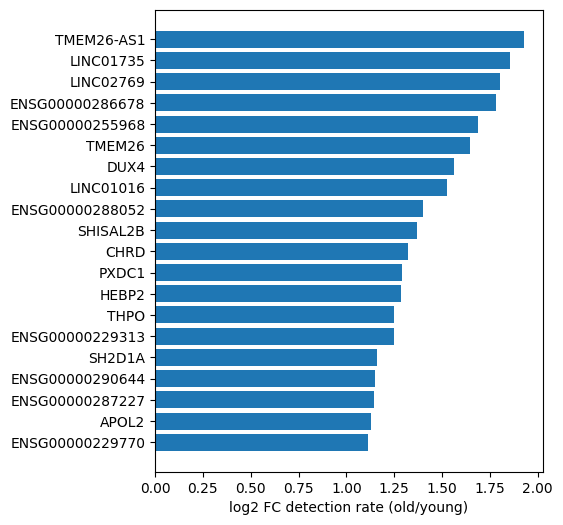

In [9]:
# pick one results_df (same for all zones within a thr)
rd = all_results[(score_method, thr, ZONES[0])].sort_values("logFC_detect", ascending=False)
top = rd.head(20)

fig, ax = plt.subplots(figsize=(5, 6))
ax.barh(top["gene"], top["logFC_detect"])
ax.set_xlabel("log2 FC detection rate (old/young)")
ax.invert_yaxis()

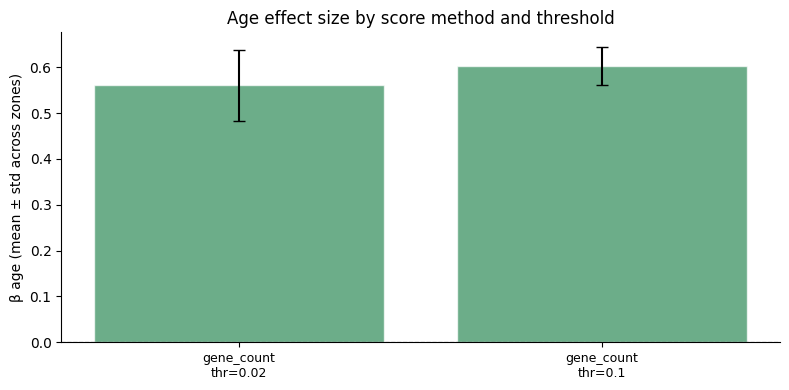

In [10]:
# average β (age coefficient) across all zones,
# Mean across zones = overall age effect size
# Std across zones = how consistent that effect is across brain regions
# ONYL DOABLE IF WE USED SCALED SCORES --> comparabel acorss zones

rows = []
for (sm, thr, zone), m in all_models.items():
    rows.append({"score_method": sm, "thr": thr,
                 "beta": m.params["age_scaled"], "pval": m.pvalues["age_scaled"]})
df_models = pd.DataFrame(rows)

g = df_models.groupby(["score_method", "thr"])
means = g["beta"].mean()
stds  = g["beta"].std()

fig, ax = plt.subplots(figsize=(8, 4))

for i, (key, mean) in enumerate(means.items()):
    ax.bar(i, mean, yerr=stds[key], capsize=4, color="seagreen", alpha=0.7, edgecolor="white")

ax.set_xticks(range(len(means)))
ax.set_xticklabels([f"{sm}\nthr={thr}" for sm, thr in means.index], fontsize=9)
ax.axhline(0, color="black", linewidth=0.8, linestyle="--")
ax.set_ylabel("β age (mean ± std across zones)")
ax.set_title("Age effect size by score method and threshold")
sns.despine()
plt.tight_layout()
plt.show()


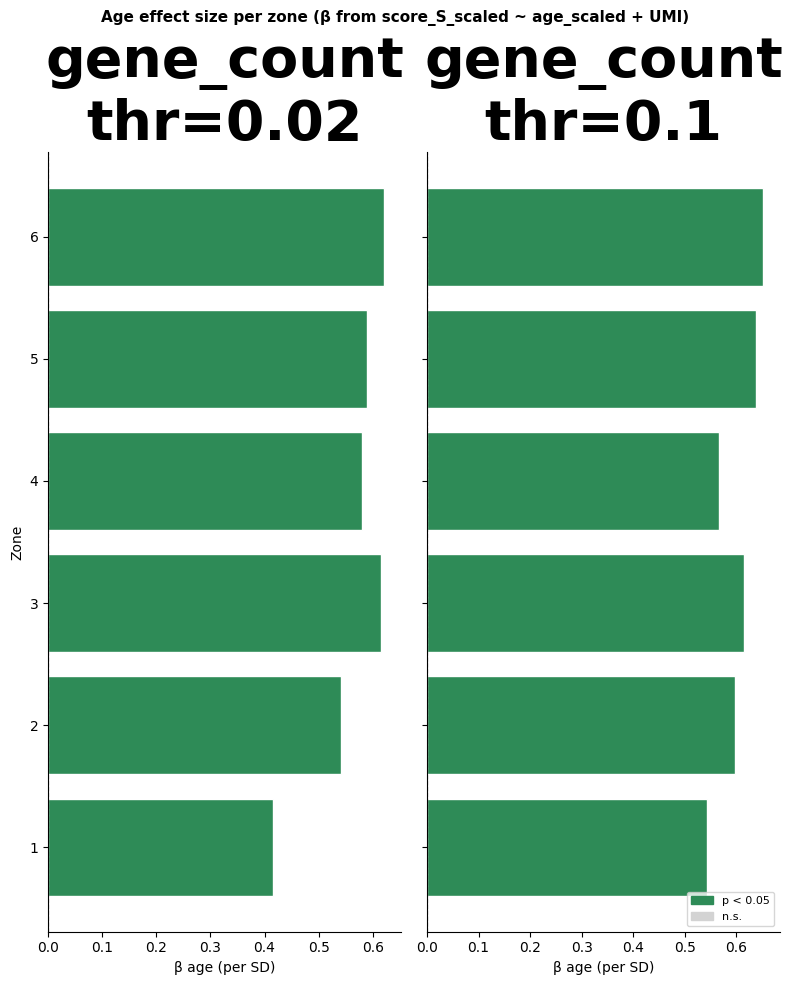

In [11]:
# Extract β per (score_method, thr, zone)
rows = []
for (sm, thr, zone), m in all_models.items():
    rows.append({
        "score_method": sm, "thr": thr, "zone": str(zone),
        "beta":  m.params["age_scaled"],
        "pval":  m.pvalues["age_scaled"],
    })
df_beta = pd.DataFrame(rows)
df_beta["sig"] = df_beta["pval"] < 0.05

# One panel per (score_method, thr)
combos  = df_beta[["score_method","thr"]].drop_duplicates().values
n_cols  = len(combos)
fig, axes = plt.subplots(1, n_cols, figsize=(4 * n_cols, 10), sharey=True)
if n_cols == 1:
    axes = [axes]

for ax, (sm, thr) in zip(axes, combos):
    sub = df_beta[(df_beta.score_method == sm) & (df_beta.thr == thr)].sort_values("zone")
    colors = ["seagreen" if s else "lightgray" for s in sub["sig"]]
    ax.barh(sub["zone"], sub["beta"], color=colors, edgecolor="white")
    ax.axvline(0, color="black", linewidth=0.8, linestyle="--")
    ax.set_title(f"{sm}\nthr={thr}", fontsize=40, fontweight="bold")
    ax.set_xlabel("β age (per SD)")
    if ax == axes[0]:
        ax.set_ylabel("Zone")

# legend
import matplotlib.patches as mpatches
axes[-1].legend(handles=[
    mpatches.Patch(color="seagreen",  label="p < 0.05"),
    mpatches.Patch(color="lightgray", label="n.s."),
], fontsize=8, loc="lower right")

fig.suptitle("Age effect size per zone (β from score_S_scaled ~ age_scaled + UMI)",
             fontsize=11, fontweight="bold")
sns.despine()
plt.tight_layout()
plt.show()


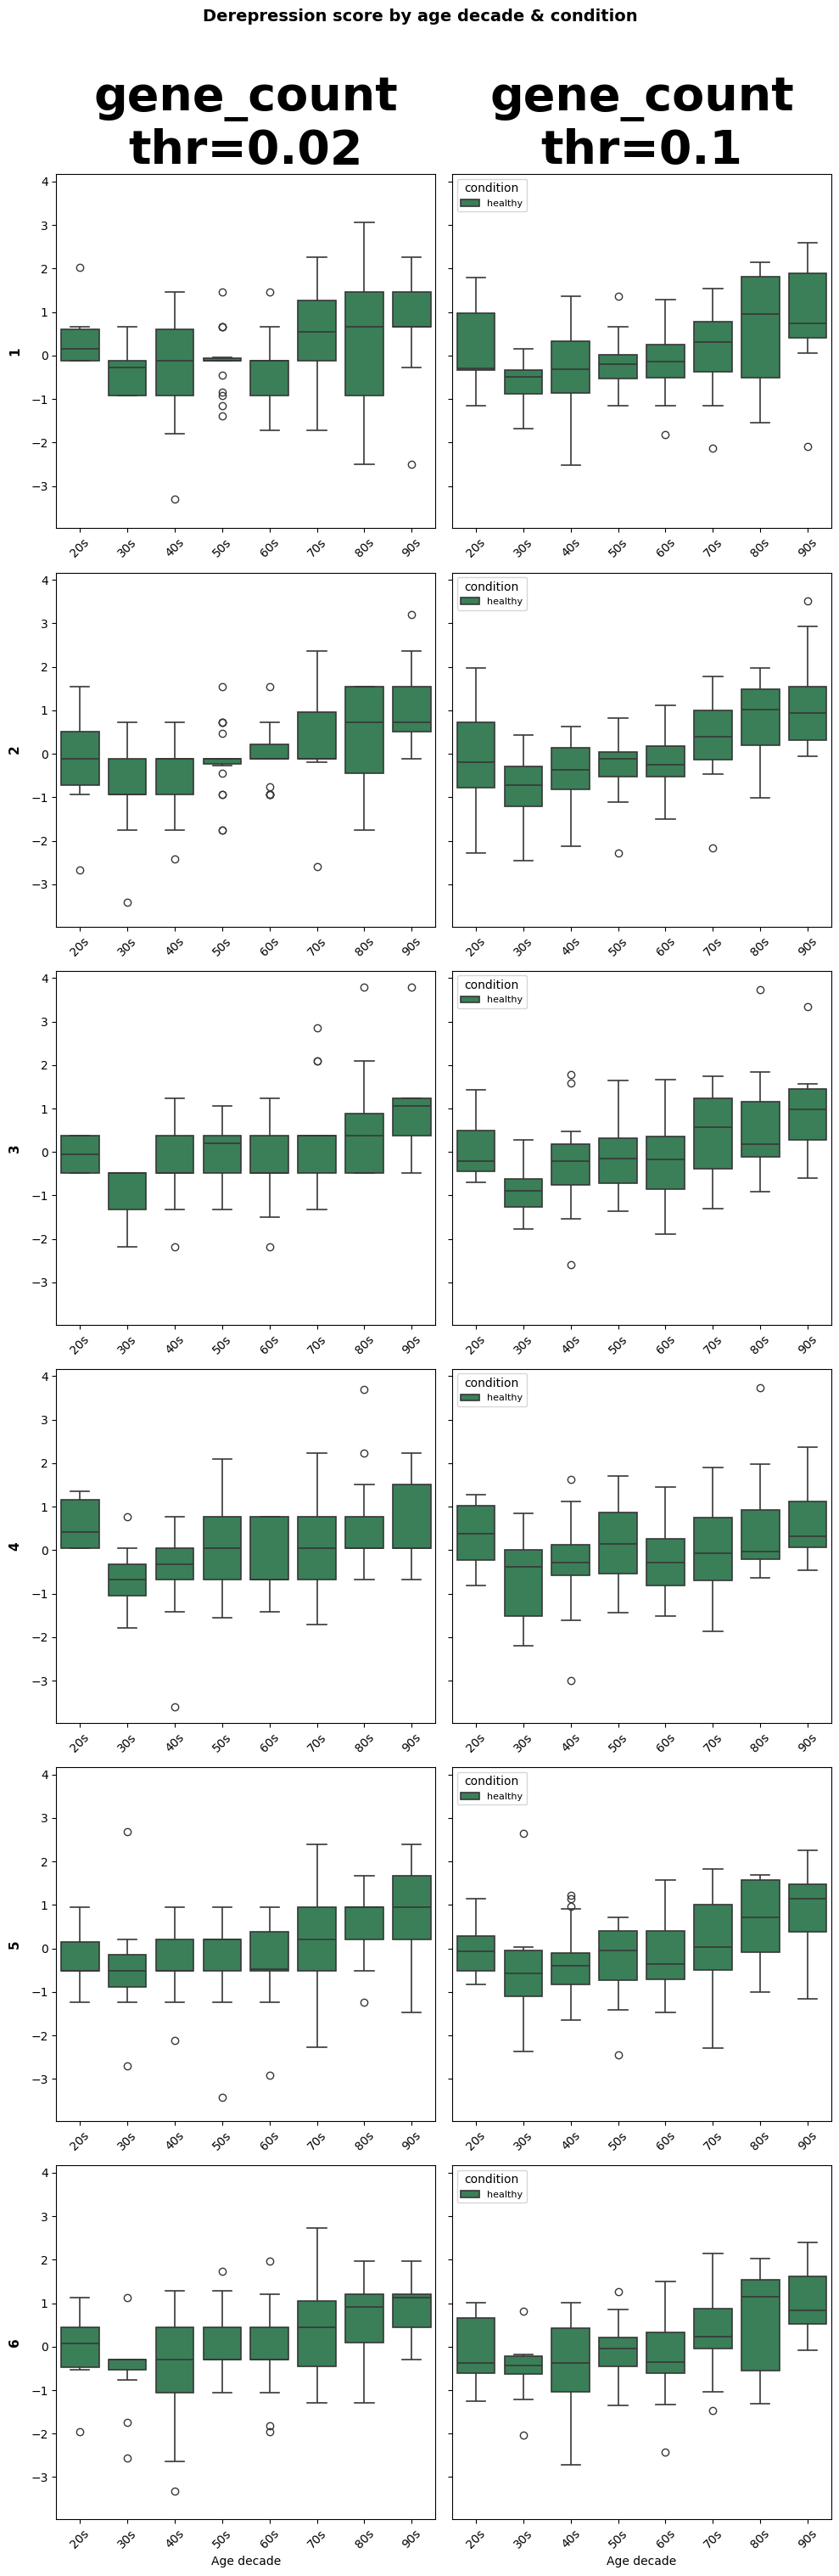

In [14]:
import math
import itertools

SCORE_COL = "score_S_scaled"

def add_decade(df):
    df = df.copy()
    df["age_decade"] = (df["age"] // 10 * 10).astype(int).astype(str) + "s"
    return df

combos   = list(itertools.product(DEREPRESSION_SCORE_METHOD, THR_DR))
n_rows   = len(ZONES)
n_cols   = len(combos)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 5 * n_rows), sharey=True)

if n_rows == 1:
    axes = axes[np.newaxis, :]
if n_cols == 1:
    axes = axes[:, np.newaxis]

for row_idx, zone in enumerate(ZONES):
    for col_idx, (score_method, thr) in enumerate(combos):
        ax  = axes[row_idx, col_idx]
        key = (score_method, thr, zone)

        if key not in all_summaries:
            ax.set_visible(False)
            continue

        df_zone      = add_decade(all_summaries[key])
        decade_order = sorted(
            df_zone["age_decade"].unique(),
            key=lambda x: int(x[:-1])
        )

        sns.boxplot(
            data      = df_zone,
            x         = "age_decade",
            y         = SCORE_COL,
            hue       = CONDITION,
            order     = decade_order,
            palette   = {"healthy": "seagreen", "diseased": "lightcoral"},
            linewidth = 1.2,
            ax        = ax,
        )

        # Column header (combo) only on first row
        if row_idx == 0:
            ax.set_title(f"{score_method}\nthr={thr}", fontsize=40, fontweight="bold")

        # Row label (zone) only on first column
        if col_idx == 0:
            ax.set_ylabel(zone, fontsize=11, fontweight="bold", labelpad=8)
        else:
            ax.set_ylabel("")

        ax.set_xlabel("Age decade" if row_idx == n_rows - 1 else "")
        ax.tick_params(axis="x", labelrotation=45)

        # Legend only on last column
        if col_idx == n_cols - 1:
            ax.legend(title=CONDITION, fontsize=8, loc="upper left")
        else:
            ax.get_legend().remove() if ax.get_legend() else None

fig.suptitle(
    "Derepression score by age decade & condition",
    y=1.01, fontsize=14, fontweight="bold"
)
plt.tight_layout()
plt.show()

# Check for PRC2 enrichment (same all zones)

In [16]:
prc2_genes = {

    # --- PRC2 complex ---
    "prc2_enzymatic_components":        ["EZH1", "EZH2"],
    "prc2_nonenzymatic_components":     ["SUZ12", "JARID2"],
    "h3k27me3_demethylases":            ["KDM6B", "KDM6A"],

    "supp_table_3_PRC2_paper": [
        'POU4F2', 'TWIST1', 'ALDH1A2', 'IRX5', 'CALCR', 'CDKN2A', 'SKOR1', 'PITX2',
        'HOXC8', 'WT1', 'SFMBT2', 'POU4F1', 'TAL1', 'PNMT', 'DSP', 'CDHR1', 'SPP1',
        'HOXD8', 'NKX6-1', 'HOXC4', 'RIPK4', '4933436C20RIK', 'LECT1', 'ALDH1A7',
        'PYGL', 'DMRT3', 'TFAP2C', 'FST', 'GPR101', 'RUNX3', 'ONECUT2', 'BARX1',
        'AMN', 'TMEM30B', 'IRX3', 'CCND1', 'IRX2', 'S100A10', 'FAM196B', 'LGALS3',
        'SIX6', 'COX6B2', 'TBX2', 'CD44', 'ASB4', 'PTPLAD2', 'SCARF2', 'VGLL2',
        'BNC2', 'LYPD1', 'GATA3', 'OTOF', 'HOXD10', 'HOXA9', 'HOXC10', 'SLC6A5',
        'LBX1', 'HOXA5', 'TBX20', 'HAND2', 'HOXD9', 'HOXB7', 'HOXB8', 'MNX1',
        'DMRTA2', 'FOXF1', 'SIM2', 'GATA6', 'SIX2', 'LUM', 'GATA2', 'PMAIP1',
        'HOXA10', 'BHLHE22', 'FOXD1', 'PITX1', 'PAX1', 'FOXL2OS', 'HMX1', 'TBX3',
        'FOXA1', 'EBF3', 'SIM1', '1500016L03RIK', 'HOXB13', 'EN1', 'SERPINA3N',
        'RGNEF', 'HOXD13', 'LHX5', 'HOXA7', 'BC061194', 'HOXC5', 'NEUROD1', 'TFAP2A',
        'HOXB5', 'SHOX2', 'TFAP2B', 'NEUROD2', '2610027K06RIK', 'TLX1', 'TNNT2',
        'SULT1A1', 'VAX2', '1500011B03RIK', 'RPRD2', 'HOXD11', 'CDKN1A', 'NEUROG2',
        'EOMES', 'PLIN4', 'TPBG', '4930447C04RIK', 'SSTR3', 'DLK1', 'PRDM8',
        'E030030I06RIK', 'CES1D', 'HOXA4', 'NRN1', 'VSX2', 'AI448005', 'GFI1',
        'ADCYAP1', 'LHX1', 'NKX3-1', 'LHX9', 'ZIC2', 'MATN2', 'HOXB3', 'KRT1',
        'IGFBP3', 'FBN1', 'OVGP1', 'CDKN2B', 'HOXB2', 'HEYL', 'GSTA3', 'NKX2-5',
        'TSHZ2', 'FOXD2', 'ALDOC', 'HMGCS2', 'DLX4', 'C130021I20RIK', 'SIX1', 'GRP',
        'COL23A1', 'CIRBP', 'A030001D16RIK', 'HOXB6', 'LMX1B', 'CBX4', 'RPRM',
        'PAX3', 'MFSD4', 'GPR50', 'SFRP2', 'UGT1A1', 'UGT1A10', 'UGT1A2', 'UGT1A5',
        'UGT1A6A', 'UGT1A6B', 'UGT1A7C', 'UTG1A9', 'ISLR', 'ASB5', 'MYCL1',
        'TRP53I11', 'SDC1', '9530018H14RIK', 'GATA4', 'BEND5', 'GM15453', 'RBM3',
        'FXYD7', 'FOXL2', '1700109F18RIK', 'GM8350', 'ZFP644', '4933439C10RIK',
        'ONECUT1', 'DAB1', 'ZFAND4', 'RPP25', 'CLDN3', 'SLC6A7', 'SERPINB1B',
        'COLEC11', 'S100A8', 'COL6A2', 'CYBRD1', 'MMD', 'GALNTL1', 'GNA13', 'ALX1',
        'NTF3', 'GRHL1', 'HOXA3', 'FHOD3', 'GREB1L', 'PAMR1', 'CPA6', 'DMRT2',
        'CPNE6', '9330171B17RIK', 'BID', 'C1QTNF1', 'KAZALD1', 'HOXD3', 'SLCO4A1',
        'S100A9', 'MYO5B', 'ANXA1', 'ACY3', 'SH2B2'
    ],

    # --- Death-promoting genes silenced by PRC2 ---
    "death_promoting_silenced_by_prc2": ["PMAIP1", "BID", "CDKN2A", "CDKN2B", "CCND1", "WT1", "IGFBP3", "TP73", "CDKN1A"],

    # --- MSN identity genes (secondarily downregulated) ---
    "msn_identity_genes_downregulated": ["DRD1", "DRD2", "ADORA2A", "PDE10A", "ARPP21", "RGS9", "FOXP1", "RXRG", "BCL11B", "GPR6", "KCND2", "PPP1R1B"],

    # --- Purkinje cell identity genes lost ---
    "purkinje_cell_genes_lost":         ["CALB1", "PCP2", "PVALB", "RORA", "FXN", "EBF3", "LHX1", "LHX5"],

    # --- Non-MSN transcription factors de-repressed ---
    "hox":           ["HOXA3", "HOXA4", "HOXA5", "HOXA7", "HOXA9", "HOXA10", "HOXB2", "HOXB3", "HOXB5", "HOXB6", "HOXB7", "HOXB8", "HOXB13", "HOXC4", "HOXC5", "HOXC8", "HOXC10", "HOXD3", "HOXD8", "HOXD9", "HOXD10", "HOXD11", "HOXD13"],
    "t_box":         ["EOMES", "TBX2", "TBX3", "TBX20"],
    "pou":           ["POU4F1", "POU4F2"],
    "gata":          ["GATA2", "GATA3", "GATA4", "GATA6"],
    "cardiac":       ["NKX2-5", "HAND2", "TWIST1", "TNNT2"],
    "hematopoietic": ["TAL1", "RUNX3"],
    "pituitary":     ["PITX1", "PITX2"],
    "neuronal":      ["NEUROD1", "NEUROD2", "NEUROG2", "NRN1"],
    "lim":           ["LHX1", "LHX5", "LHX9"],
    "hypothalamic":  ["SIM1", "SIM2"],
    "forkhead":      ["FOXA1", "FOXD1", "FOXD2", "FOXL2", "FOXL2OS"],
    "other_tfs":     ["ZIC2", "EN1", "ONECUT1", "BARX1", "SFMBT2", "BHLHE22", "DLX4", "EBF3", "FOXF1", "GRHL1", "IRX2", "IRX3", "IRX5", "LBX1", "LMX1B", "NKX3-1", "NKX6-1", "PAX1", "PAX3", "PAX6", "SHOX2", "SIX1", "SIX2", "SIX6", "TLX1", "CBX4", "DMRT2", "DMRT3", "DMRTA2", "VSX2", "MNX1", "TFAP2A", "MYCL1", "HEYL", "DAB1"],

    # --- Non-TF genes upregulated in PRC2-deficient MSNs ---
    "non_tf_upregulated": ["SFRP2", "DLK1", "NTF3", "FBN1", "MATN2", "COL6A2", "COL23A1", "C1QTNF1", "COLEC11", "ISLR", "TPBG", "SDC1", "SH2B2", "GNA13", "RGNEF", "DAB1", "SSTR3", "RIPK4", "PLIN4", "CIRBP", "HEYL", "GRP", "PYGL", "ALDOC", "GSTA3", "S100A8", "S100A10", "SLC6A7", "SLCO4A1", "MFSD4", "CLDN3", "TMEM30B", "AMN", "CPA6", "DSP", "CYBRD1", "KAZALD1", "MMD", "ACY3", "GALNTL1", "SERPINB1", "SERPINA3"],
}

adata_genes = set(bican.var_names)

for family, genes in prc2_genes.items():
    found    = [g for g in genes if g in adata_genes]
    missing  = [g for g in genes if g not in adata_genes]
    print(f"{family:40s}  {len(found)}/{len(genes)}  found: {found}")

prc2_enzymatic_components                 2/2  found: ['EZH1', 'EZH2']
prc2_nonenzymatic_components              2/2  found: ['SUZ12', 'JARID2']
h3k27me3_demethylases                     2/2  found: ['KDM6B', 'KDM6A']
supp_table_3_PRC2_paper                   182/217  found: ['POU4F2', 'TWIST1', 'ALDH1A2', 'IRX5', 'CALCR', 'CDKN2A', 'SKOR1', 'PITX2', 'HOXC8', 'WT1', 'SFMBT2', 'POU4F1', 'TAL1', 'PNMT', 'DSP', 'CDHR1', 'SPP1', 'HOXD8', 'NKX6-1', 'HOXC4', 'RIPK4', 'PYGL', 'DMRT3', 'TFAP2C', 'FST', 'GPR101', 'RUNX3', 'ONECUT2', 'BARX1', 'AMN', 'TMEM30B', 'IRX3', 'CCND1', 'IRX2', 'S100A10', 'LGALS3', 'SIX6', 'COX6B2', 'TBX2', 'CD44', 'ASB4', 'SCARF2', 'VGLL2', 'BNC2', 'LYPD1', 'GATA3', 'OTOF', 'HOXD10', 'HOXA9', 'HOXC10', 'SLC6A5', 'LBX1', 'HOXA5', 'TBX20', 'HAND2', 'HOXD9', 'HOXB7', 'HOXB8', 'MNX1', 'DMRTA2', 'FOXF1', 'SIM2', 'GATA6', 'SIX2', 'LUM', 'GATA2', 'PMAIP1', 'HOXA10', 'BHLHE22', 'FOXD1', 'PITX1', 'PAX1', 'HMX1', 'TBX3', 'FOXA1', 'EBF3', 'SIM1', 'HOXB13', 'EN1', 'HOXD13', 'LHX5', 

In [28]:
list_results = []

for score_method in DEREPRESSION_SCORE_METHOD:
    for thr in THR_DR:
        # results_df comes from find_depressed_genes on ALL striatum — same for every zone
        key = (score_method, thr, ZONES[0])
        if key not in all_results:
            continue

        for gene_family in prc2_genes:
            result = derepression_functions.polycomb_enrichment_cmh(
                all_results[key].copy(),
                prc2_genes[gene_family],
                fdr_alpha=0.05, n_bins=20,
            )
            result["score_method"] = score_method
            result["thr"]          = thr
            result["gene_family"]  = gene_family
            list_results.append(result)

# ── Build tidy DataFrame ───────────────────────────────────────────────────
INDEX_COLS  = ["score_method", "thr", "gene_family"]
RESULT_COLS = ["odds_ratio", "pval", "overlap", "overlap_genes",
               "n_sig", "n_pc_cands", "n_candidates", "n_strata"]


df_polycomb_enrichment = (
    pd.DataFrame(list_results)
      [INDEX_COLS + RESULT_COLS]
      .sort_values(INDEX_COLS)
      .reset_index(drop=True)
)

df_polycomb_enrichment


/home/gdallagl/myworkdir/XDP/.venv/lib/python3.11/site-packages/statsmodels/stats/contingency_tables.py:1077: RuntimeWarning: invalid value encountered in scalar divide
  odds_ratio = np.sum(self._ad / self._n) / np.sum(self._bc / self._n)
/home/gdallagl/myworkdir/XDP/.venv/lib/python3.11/site-packages/statsmodels/stats/contingency_tables.py:1058: RuntimeWarning: invalid value encountered in scalar divide
  statistic /= denom


,score_method,thr,gene_family,odds_ratio,pval,overlap,overlap_genes,n_sig,n_pc_cands,n_candidates,n_strata
0,gene_count,0.02,cardiac,0.000000,0.628428,0,[],297,4,14220,16
1,gene_count,0.02,death_promoting_silenced_by_prc2,0.000000,0.598143,0,[],297,4,14220,16
2,gene_count,0.02,forkhead,0.000000,0.637779,0,[],297,4,14220,16
3,gene_count,0.02,gata,0.000000,0.613003,0,[],297,4,14220,16
4,gene_count,0.02,h3k27me3_demethylases,NaN,NaN,0,[],297,0,14220,16
5,gene_count,0.02,hematopoietic,0.000000,0.577471,0,[],297,2,14220,16
6,gene_count,0.02,hox,0.000000,0.755317,0,[],297,23,14220,16
7,gene_count,0.02,hypothalamic,0.000000,0.565569,0,[],297,1,14220,16
8,gene_count,0.02,lim,0.000000,0.543669,0,[],297,2,14220,16
9,gene_count,0.02,msn_identity_genes_downregulated,NaN,NaN,0,[],297,0,14220,16


In [29]:
display(df_polycomb_enrichment[df_polycomb_enrichment.pval < 0.05])

display(df_polycomb_enrichment[df_polycomb_enrichment.overlap > 0])

display(df_polycomb_enrichment[df_polycomb_enrichment.n_pc_cands > 0])

,score_method,thr,gene_family,odds_ratio,pval,overlap,overlap_genes,n_sig,n_pc_cands,n_candidates,n_strata
10,gene_count,0.02,neuronal,14.961794,0.000938,1,[NEUROD2],297,3,14220,16
21,gene_count,0.10,death_promoting_silenced_by_prc2,9.533592,0.009592,2,"[CCND1, WT1]",787,8,21201,18
28,gene_count,0.10,lim,15.898574,0.000299,1,[LHX9],787,3,21201,18
30,gene_count,0.10,neuronal,11.976181,0.002468,1,[NEUROD2],787,4,21201,18


,score_method,thr,gene_family,odds_ratio,pval,overlap,overlap_genes,n_sig,n_pc_cands,n_candidates,n_strata
10,gene_count,0.02,neuronal,14.961794,0.000938,1,[NEUROD2],297,3,14220,16
11,gene_count,0.02,non_tf_upregulated,4.235954,0.063964,1,[GRP],297,14,14220,16
18,gene_count,0.02,supp_table_3_PRC2_paper,0.868208,0.579615,2,"[GRP, NEUROD2]",297,111,14220,16
21,gene_count,0.10,death_promoting_silenced_by_prc2,9.533592,0.009592,2,"[CCND1, WT1]",787,8,21201,18
28,gene_count,0.10,lim,15.898574,0.000299,1,[LHX9],787,3,21201,18
30,gene_count,0.10,neuronal,11.976181,0.002468,1,[NEUROD2],787,4,21201,18
31,gene_count,0.10,non_tf_upregulated,1.104363,0.460565,1,[GRP],787,24,21201,18
38,gene_count,0.10,supp_table_3_PRC2_paper,1.284450,0.299274,5,"[CCND1, GRP, LHX9, NEUROD2, WT1]",787,139,21201,18


,score_method,thr,gene_family,odds_ratio,pval,overlap,overlap_genes,n_sig,n_pc_cands,n_candidates,n_strata
0,gene_count,0.02,cardiac,0.000000,0.628428,0,[],297,4,14220,16
1,gene_count,0.02,death_promoting_silenced_by_prc2,0.000000,0.598143,0,[],297,4,14220,16
2,gene_count,0.02,forkhead,0.000000,0.637779,0,[],297,4,14220,16
3,gene_count,0.02,gata,0.000000,0.613003,0,[],297,4,14220,16
5,gene_count,0.02,hematopoietic,0.000000,0.577471,0,[],297,2,14220,16
6,gene_count,0.02,hox,0.000000,0.755317,0,[],297,23,14220,16
7,gene_count,0.02,hypothalamic,0.000000,0.565569,0,[],297,1,14220,16
8,gene_count,0.02,lim,0.000000,0.543669,0,[],297,2,14220,16
10,gene_count,0.02,neuronal,14.961794,0.000938,1,[NEUROD2],297,3,14220,16
11,gene_count,0.02,non_tf_upregulated,4.235954,0.063964,1,[GRP],297,14,14220,16


# Load NucSeq

In [46]:
nucseq.obs[CONDITION]

barcode
A22KHKGLT3__pXDPsHSrPuiv1d240321rxn4__CAGCATACATTGTGCA-1_Striatum_SCF-20-025            XDP
A22KHKGLT3__pXDPsHSrPuiv1d240321rxn4__CACATTTGTTGATTGC-1_Striatum_SCF-18-004            XDP
A22KHKGLT3__pXDPsHSrPuiv1d240321rxn4__GCAAACTCACTCTGTC-1_Striatum_SCF-20-025            XDP
A22KHKGLT3__pXDPsHSrPuiv1d240321rxn4__TACTCATTCTCTGCTG-1_Striatum_SCF-22-058CF      Control
A22KHKGLT3__pXDPsHSrPuiv1d240321rxn4__ACTGATGTCTTCTGGC-1_Striatum_SCF-18-003            XDP
                                                                                     ...   
250328_SL-EXE_0516_A22N2VFLT4__SI-TT-H12__ACGCCGGGTGGAATCT-1_Striatum_SCF-19-020        XDP
250328_SL-EXE_0516_A22N2VFLT4__SI-TT-H12__AGAGGTTAGAGTGGCA-1_Striatum_SCF_23-083        XDP
250328_SL-EXE_0516_A22N2VFLT4__SI-TT-H12__CCCTTTACAGTAAGAT-1_Striatum_SCF_22-060        XDP
250328_SL-EXE_0516_A22N2VFLT4__SI-TT-H12__CCCTTCGCAAGTCTTA-1_Striatum_SCF_22-060        XDP
250328_SL-EXE_0516_A22N2VFLT4__SI-TT-H12__AGAATCAAGAGCGGAC-1_Striatum_SC

In [ ]:
ADATA_PATH = "/home/gdallagl/myworkdir/XDP/data/XDP/NucSec/adatas/Striatum/Striatum_combined_QC_mmc_ct-cured_zoned.h5ad"
nucseq = sc.read_h5ad(ADATA_PATH, backed="r")

# Use gene symbols as var_names (rather than Ensembl IDs)
nucseq.var.index = nucseq.var["gene_symbol"]

# Normalise cell-type labels (replace spaces with underscores)
nucseq.obs["ct_for_deg"] = nucseq.obs["ct_for_deg"].str.replace(" ", "_")

# Select only D1 Matrix
nucseq = nucseq[nucseq.obs["ct_for_deg"] == "Matrix_D1"].to_memory().copy()

# Rename columns to a consistent naming convention
nucseq.obs = nucseq.obs.rename(columns={
    "zone"         : ZONE_COL,
    "donor_id"     : SAMPLE_VARIABLE,
    "age_of_death" : AGE,
    "total_counts" : LIBRARY_SIZE_COL,
    "sex"  : "sex",
})
nucseq.obs[CONDITION] = nucseq.obs[CONDITION].map({"Control": HEALTHY_CONDITION, "XDP": DISEASED_CONDITION})

print(nucseq)

AnnData object with n_obs × n_vars = 11459 × 38601
    obs: 'background_fraction', 'cell_probability', 'cell_size', 'droplet_efficiency', 'barcode', 'bcl', 'rna_index', 'library', 'library__barcode', 'frac_mito', 'mol_info_nUMI', 'mol_info_nRead', 'frac_intronic', 'donor_id', 'vireo_prob_max', 'vireo_prob_doublet', 'vireo_n_vars', 'vireo_best_singlet', 'vireo_best_doublet', 'vireo_doublet_logLikRatio', 'dropsift_frac_contamination', 'dropsift_training_label_is_cell', 'dropsift_empty_gene_module_score', 'dropsift_is_cell', 'dropsift_is_cell_prob', 'cell_class', 'leiden_0.1', 'leiden_0.2', 'leiden_0.3', 'leiden_0.4', 'leiden_0.5', 'tissue', 'broad_original_cell_type', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'brain_bank', 'cohort', 'condition', 'sex', 'age_of_ons

# NucSeq Healthy derepresion

Use prevuos gouf list of genes

In [31]:
print("Keys in all_gene_lists:", list(all_gene_lists.keys())[:3])
print("ZONES from nucseq:", ZONES[:])


Keys in all_gene_lists: [('gene_count', 0.02, 1), ('gene_count', 0.02, 2), ('gene_count', 0.02, 3)]
ZONES from nucseq: [1, 2, 3, 4, 5, 6]


In [ ]:
# ── CHOOSE THE PARAMETER THAT DEFINES THE GENE LIST ─────────────────────────
SCORE_METHOD = "gene_count"
THR          = 0.1
SCORE_COL    = "score_S_scaled"

# ── Build long dataframe ──────────────────────────────────────────────────────
valid_zones = [z for z in sorted(nucseq.obs[ZONE_COL].dropna().unique())
               if (SCORE_METHOD, THR, int(z)) in all_gene_lists]

rows = []
for zone in valid_zones:
    key = (SCORE_METHOD, THR, int(zone))

    nucseq_zone = nucseq[(nucseq.obs[ZONE_COL] == zone) &
                         (nucseq.obs[CONDITION] == HEALTHY_CONDITION)].copy()
    
    print(nucseq_zone)
    sumamary = derepression_functions.compute_scores_and_cov(
        nucseq_zone, gene_set=all_gene_lists[key],
        donor_col=SAMPLE_VARIABLE, age_col=AGE,
        umi_col=LIBRARY_SIZE_COL, condition_col=CONDITION,
        score_method=SCORE_METHOD, percentile=90,
    )

    model = smf.ols("score_S_scaled ~ age_scaled + median_log_umi_scaled", data=summary).fit()
    b, p  = model.params["age_scaled"], model.pvalues["age_scaled"]
    print(f"\t{zone}: {len(gene_list)} genes | β={b:+.3f} p={p:.2e}")

df_all = pd.concat(rows, ignore_index=True)


AnnData object with n_obs × n_vars = 1483 × 38601
    obs: 'background_fraction', 'cell_probability', 'cell_size', 'droplet_efficiency', 'barcode', 'bcl', 'rna_index', 'library', 'library__barcode', 'frac_mito', 'mol_info_nUMI', 'mol_info_nRead', 'frac_intronic', 'donor_id', 'vireo_prob_max', 'vireo_prob_doublet', 'vireo_n_vars', 'vireo_best_singlet', 'vireo_best_doublet', 'vireo_doublet_logLikRatio', 'dropsift_frac_contamination', 'dropsift_training_label_is_cell', 'dropsift_empty_gene_module_score', 'dropsift_is_cell', 'dropsift_is_cell_prob', 'cell_class', 'leiden_0.1', 'leiden_0.2', 'leiden_0.3', 'leiden_0.4', 'leiden_0.5', 'tissue', 'broad_original_cell_type', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'brain_bank', 'cohort', 'condition', 'sex', 'age_of_onse

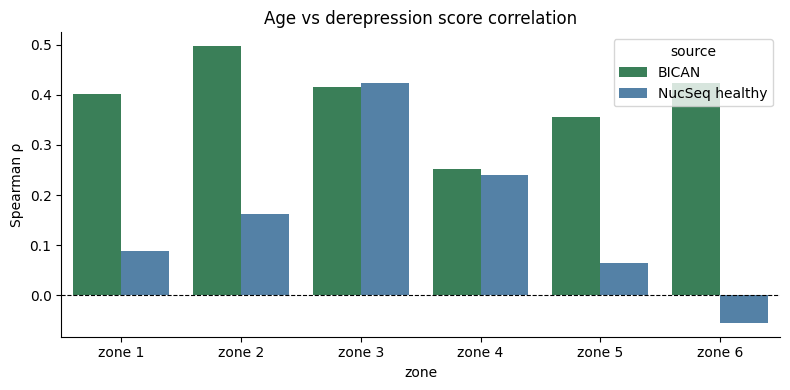

In [60]:
# Unlike β, ρ is scale-free and unit-free — it only measures whether older donors tend to have higher scores than younger ones, regardless of how the score is normalized. This makes BICAN and NucSeq directly comparable on the same axis.
# If both bars are similar height and both significant → the age-derepression relationship replicates with the same strength in both datasets.

from scipy.stats import spearmanr

SCORE_COL = "score_S_scaled"

rows = []
for (zone, source), grp in df_all.groupby(["zone", "source"]):
    r, p = spearmanr(grp["age_scaled"], grp[SCORE_COL])
    rows.append({"zone": zone, "source": source, "rho": r, "pval": p})

df_rho = pd.DataFrame(rows)

fig, ax = plt.subplots(figsize=(8, 4))
sns.barplot(data=df_rho, x="zone", y="rho", hue="source",
            palette={"BICAN": "seagreen", "NucSeq healthy": "steelblue"}, ax=ax)
ax.axhline(0, color="black", linewidth=0.8, linestyle="--")
ax.set_ylabel("Spearman ρ")
ax.set_title("Age vs derepression score correlation")
sns.despine()
plt.tight_layout()
plt.show()


# XDP derepression

In [ ]:
for zone, gene_list in all_gene_lists.items():
    print(f"\n\nProcessing zone: {zone}")

    bican_zone = bican[bican.obs[ZONE_COL] == zone].copy()
    nucseq_zone = nucseq[nucseq.obs[ZONE_COL] == zone].copy()



    # Remove donors with fewer than N cells (too noisy for detection-rate estimates)
    MIN_CELLS_PER_DONOR = 10

    def filter_low_cell_donors(adata, sample_col, min_cells):
        counts    = adata.obs[sample_col].value_counts()
        keep      = counts[counts >= min_cells].index
        return adata[adata.obs[sample_col].isin(keep)].copy()

    nucseq_zone = filter_low_cell_donors(nucseq_zone, SAMPLE_VARIABLE, MIN_CELLS_PER_DONOR)
    bican_zone = filter_low_cell_donors(bican_zone, SAMPLE_VARIABLE, MIN_CELLS_PER_DONOR)

    print(f"After filtering — NucSeq: {nucseq_zone.obs[SAMPLE_VARIABLE].nunique()} donors")
    print(f"After filtering — BICAN:  {bican_zone.obs[SAMPLE_VARIABLE].nunique()} donors")




    # Subset samples in H (both dataset) to only have the same age range of D?





    # calculte scores INDEPEDENLTY
    SCORE_TYPE = "scanpy_score"
    summary_nucseq = derepression_functions.compute_scores_and_cov(
        nucseq_zone, gene_set=gene_list, donor_col=SAMPLE_VARIABLE, age_col=AGE,
        umi_col=LIBRARY_SIZE_COL, condition_col=CONDITION, cov_cols=None,
        score_method=SCORE_TYPE, percentile=90,
    )
    summary_nucseq["dataset"] = "nucseq"
    summary_nucseq["zone"] = zone
    summary_bican = derepression_functions.compute_scores_and_cov(
        bican_zone, gene_set=gene_list, donor_col=SAMPLE_VARIABLE, age_col=AGE,
        umi_col=LIBRARY_SIZE_COL, condition_col=CONDITION, cov_cols=None,
        score_method=SCORE_TYPE, percentile=90,
    )
    summary_bican["dataset"] = "bican"
    summary_bican["zone"] = zone

    
    # Merge summaries
    df_merged = pd.concat([summary_nucseq, summary_bican])


    print(df_merged["age"].describe())
    # If std < 8–10 years, drop the interaction term

    # Run test
    formula = "score_S ~ age_scaled + C(condition) + age_scaled:condition + C(dataset) + median_umi_scaled" # pct90_derepressed ~ age_scaled * is_xdp + median_umi_scaled
    cov_col = None
    if cov_col:
        formula += " + " + " + ".join(cov_col)
    model = smf.ols(formula, data=df_merged).fit()





In [ ]:
MIN_CELLS_PER_DONOR = 10
SCORE_TYPE          = "scanpy_score"

def filter_low_cell_donors(adata, sample_col, min_cells):
    keep = adata.obs[sample_col].value_counts()
    keep = keep[keep >= min_cells].index
    return adata[adata.obs[sample_col].isin(keep)].copy()

zone_models = {}

for (score_method, thr, zone), gene_list in all_gene_lists.items():
    
    print(f"\n── Zone {zone} ──────────────────────────────────────────────")

    # ── 1. Subset to zone, drop low-cell donors ───────────────────────────
    bican_zone  = bican [bican.obs [ZONE_COL] == zone].copy()
    nucseq_zone = nucseq[nucseq.obs[ZONE_COL] == zone].copy()

    bican_zone  = filter_low_cell_donors(bican_zone,  SAMPLE_VARIABLE, MIN_CELLS_PER_DONOR)
    nucseq_zone = filter_low_cell_donors(nucseq_zone, SAMPLE_VARIABLE, MIN_CELLS_PER_DONOR)

    print(f"  BICAN : {bican_zone.obs [SAMPLE_VARIABLE].nunique()} donors")
    print(f"  NucSeq: {nucseq_zone.obs[SAMPLE_VARIABLE].nunique()} donors")

    # ── 2. Clip BICAN to XDP age range (avoid extrapolation) ─────────────
    xdp_ages       = nucseq_zone.obs.drop_duplicates(SAMPLE_VARIABLE)[AGE].astype(float)
    age_lo, age_hi = xdp_ages.min(), xdp_ages.max()
    bican_zone     = bican_zone[bican_zone.obs[AGE].astype(float).between(age_lo, age_hi)].copy()
    print(f"  BICAN clipped to [{age_lo:.0f}–{age_hi:.0f}] → {bican_zone.obs[SAMPLE_VARIABLE].nunique()} donors remain")

    # ── 3. Score independently per dataset ───────────────────────────────
    # Normalisation and scanpy_score background computed within each dataset
    summary_bican  = derepression_functions.compute_scores_and_cov(
        bican_zone,  gene_set=gene_list, donor_col=SAMPLE_VARIABLE, age_col=AGE,
        umi_col=LIBRARY_SIZE_COL, condition_col=CONDITION, score_method=SCORE_TYPE, percentile=90,
    )
    summary_nucseq = derepression_functions.compute_scores_and_cov(
        nucseq_zone, gene_set=gene_list, donor_col=SAMPLE_VARIABLE, age_col=AGE,
        umi_col=LIBRARY_SIZE_COL, condition_col=CONDITION, score_method=SCORE_TYPE, percentile=90,
    )
    summary_bican ["dataset"] = "bican"
    summary_nucseq["dataset"] = "nucseq"

    # ── 4. Merge and re-scale on the combined df ──────────────────────────
    # Scores were scaled independently → must redo scaling on the joint data
    df = pd.concat([summary_bican, summary_nucseq], ignore_index=True)
    df["zone"]              = zone
    df["age_scaled"]        = (df["age"]        - df["age"].mean())        / df["age"].std()
    df["median_umi_scaled"] = (df["median_umi"] - df["median_umi"].mean()) / df["median_umi"].std()

    # ── 5. OLS ────────────────────────────────────────────────────────────
    # Interaction needs enough age spread in XDP to estimate a slope within D
    if xdp_ages.std() > 8:
        formula = "score_S ~ age_scaled * C(condition) + C(dataset) + median_umi_scaled"
    else:
        formula = "score_S ~ age_scaled + C(condition) + C(dataset) + median_umi_scaled"
        print(f"  ⚠  XDP age std = {xdp_ages.std():.1f} yrs — interaction term dropped")

    model = smf.ols(formula, data=df).fit()
    print(model.summary())

    zone_models[zone] = {"model": model, "df": df}



── Zone 1 ──────────────────────────────────────────────


NameError: name 'nucseq' is not defined

## Compute scores

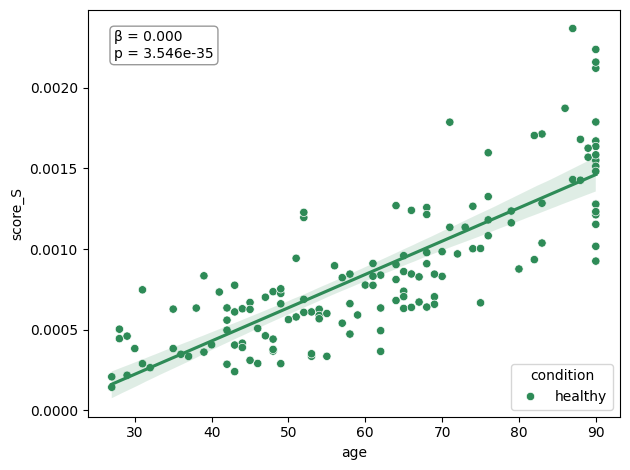

In [ ]:
from scipy import stats

# fit
slope, intercept, r_value, p_value, std_err = stats.linregress(summary["age"], summary["score_S"])

# plot
fig, ax = plt.subplots()
sns.scatterplot(data=summary, x="age", y="score_S", color="seagreen", edgecolor="white", ax=ax, hue=CONDITION, palette={"healthy": "seagreen", "diseased": "lightcoral"})
sns.regplot(data=summary, x="age", y="score_S", scatter=False, color="seagreen", ax=ax)

ax.annotate(
    f"β = {slope:.3f}\np = {p_value:.3e}",
    xy=(0.05, 0.95), xycoords="axes fraction",
    va="top", ha="left",
    fontsize=10,
    bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="gray", alpha=0.8)
)

plt.tight_layout()
plt.show()